In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f"Accelerating on: {torch.cuda.get_device_name(0)}")

Accelerating on: Tesla T4


In [22]:
data_dir = '/kaggle/input/datasets/msambare/fer2013'  

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'test']}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=True, num_workers=4, pin_memory=True) 
    for x in ['train', 'test']
}


In [23]:

class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

In [24]:

model = models.densenet121(weights='IMAGENET1K_V1')

num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 7) 

model = model.to(device)

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

epochs = 15
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=1e-3, 
    steps_per_epoch=len(dataloaders['train']), 
    epochs=epochs
)

In [26]:
from torch.amp import GradScaler, autocast

def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    scaler = GradScaler('cuda')
    total_steps_limit = num_epochs * len(dataloaders['train'])
    current_step = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        for phase in ['train', 'test']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast('cuda'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        
                       
                        before_step_scale = scaler.get_scale()
                        
                        scaler.step(optimizer)
                        scaler.update()
                        
                        
                        if current_step < total_steps_limit:
                            if scaler.get_scale() >= before_step_scale:
                                scheduler.step()
                                current_step += 1

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

model = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 1/15
train Loss: 1.2893 Acc: 0.5103
test Loss: 1.0161 Acc: 0.6138
Epoch 2/15
train Loss: 1.0088 Acc: 0.6211
test Loss: 1.1189 Acc: 0.5958
Epoch 3/15
train Loss: 0.9867 Acc: 0.6321
test Loss: 1.0161 Acc: 0.6158
Epoch 4/15
train Loss: 0.9746 Acc: 0.6341
test Loss: 1.0529 Acc: 0.6060
Epoch 5/15
train Loss: 0.9373 Acc: 0.6501
test Loss: 1.0223 Acc: 0.6188
Epoch 6/15
train Loss: 0.8962 Acc: 0.6620
test Loss: 0.9545 Acc: 0.6573
Epoch 7/15
train Loss: 0.8528 Acc: 0.6821
test Loss: 0.9295 Acc: 0.6606
Epoch 8/15
train Loss: 0.8125 Acc: 0.6955
test Loss: 0.9271 Acc: 0.6675
Epoch 9/15
train Loss: 0.7608 Acc: 0.7190
test Loss: 0.9047 Acc: 0.6794
Epoch 10/15
train Loss: 0.6942 Acc: 0.7447
test Loss: 0.9294 Acc: 0.6797
Epoch 11/15
train Loss: 0.6123 Acc: 0.7727
test Loss: 0.9000 Acc: 0.6935
Epoch 12/15
train Loss: 0.5106 Acc: 0.8120
test Loss: 0.9046 Acc: 0.7119
Epoch 13/15
train Loss: 0.3982 Acc: 0.8543
test Loss: 0.9441 Acc: 0.7151
Epoch 14/15
train Loss: 0.3129 Acc: 0.8890
test Loss: 0.9714

In [27]:
torch.save(model.state_dict(), 'densenet121_fer2013.pth')
print("DenseNet model saved successfully!")

DenseNet model saved successfully!


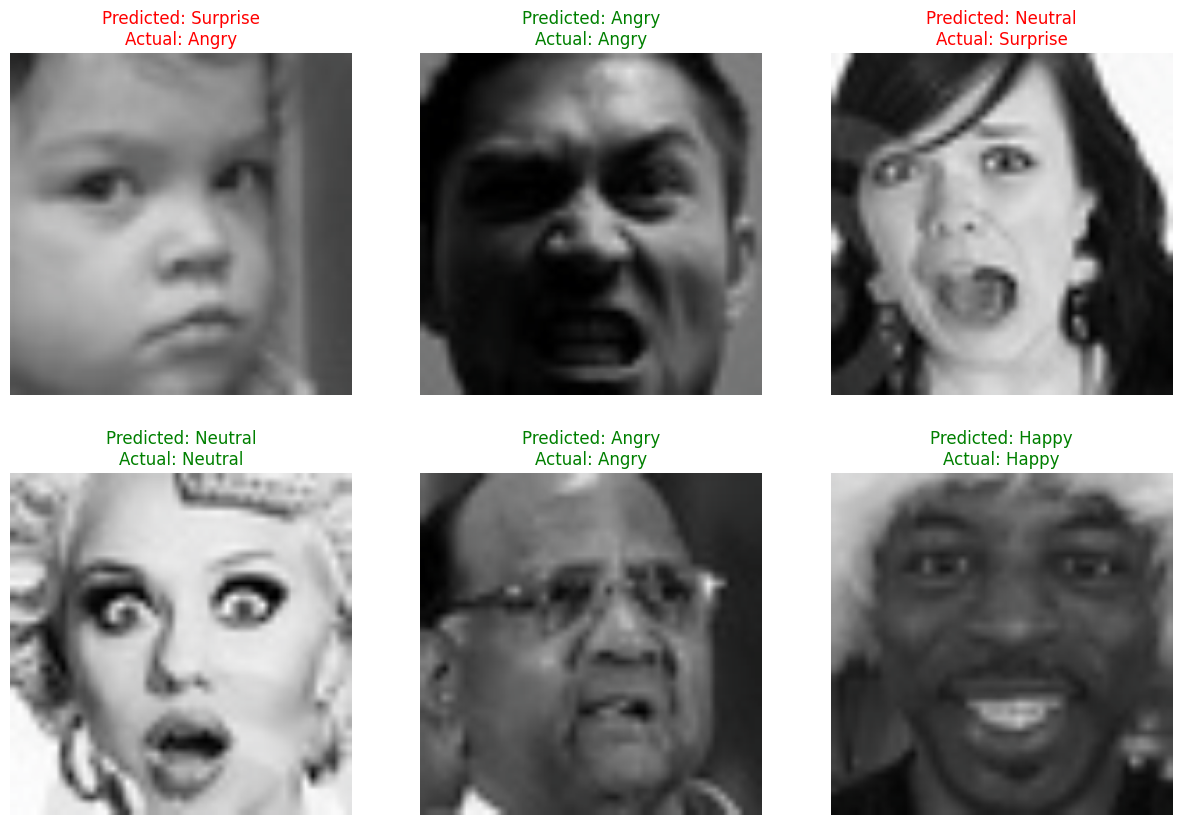

In [28]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_results(model, num_images=6):
   
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)
                ax.axis('off')
                
              
                color = 'green' if preds[j] == labels[j] else 'red'
                ax.set_title(f'Predicted: {class_names[preds[j]]}\nActual: {class_names[labels[j]]}', color=color)
                
           
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                plt.imshow(img)

                if images_so_far == num_images:
                    return


visualize_results(model)
plt.show()